In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load Dataset
data_path = "/kaggle/input/datasets/abdibakala/ember-dataset/ember2024_21k.csv.csv"
df = pd.read_csv(data_path)

print("=" * 60)
print(f"Initial Dataset Shape: {df.shape}")
print("=" * 60)

# Track removed items
removed_report = {
    "metadata_columns": [],
    "duplicate_rows": 0,
    "unlabeled_rows": 0,
    "constant_columns": []
}

# 2. Identify Target and Metadata Columns
target_col = 'Label' if 'Label' in df.columns else 'label'

# Non-numeric hashes or file metadata columns to remove
known_metadata = ['sha256', 'md5', 'appeared', 'filename', 'file_id']
metadata_cols = [c for c in known_metadata if c in df.columns]
removed_report["metadata_columns"] = metadata_cols

# Separate target and features
X = df.drop(columns=metadata_cols + [target_col], errors='ignore').copy()
y = df[target_col].copy()

# 3. Filter Out Unlabeled Data (e.g. EMBER samples with label -1)
valid_mask = y.isin([0, 1])
removed_report["unlabeled_rows"] = int((~valid_mask).sum())
X = X[valid_mask]
y = y[valid_mask]

# 4. Remove Duplicate Rows
initial_row_count = len(X)
X_dedup = X.drop_duplicates()
y = y.loc[X_dedup.index]
X = X_dedup
removed_report["duplicate_rows"] = initial_row_count - len(X)

# 5. Identify and Drop Zero-Variance / Constant Columns (Columns with only 1 unique value)
constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
removed_report["constant_columns"] = constant_cols
X.drop(columns=constant_cols, inplace=True)

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# 6. Categorize Remaining Features
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# 7. Print Removal Summary Report
print("\n" + "=" * 60)
print("REMOVAL REPORT")
print("=" * 60)
print(f"• Removed Metadata Columns ({len(removed_report['metadata_columns'])}):")
print(f"  {removed_report['metadata_columns'] if removed_report['metadata_columns'] else 'None found'}")

print(f"\n• Removed Constant / Zero-Variance Features ({len(removed_report['constant_columns'])}):")
print(f"  {removed_report['constant_columns'] if removed_report['constant_columns'] else 'None found'}")

print(f"\n• Removed Rows:")
print(f"  - Unlabeled rows removed: {removed_report['unlabeled_rows']}")
print(f"  - Duplicate rows removed: {removed_report['duplicate_rows']}")

print("\n" + "=" * 60)
print("FEATURE SUMMARY AFTER CLEANING")
print("=" * 60)
print(f"Remaining Numerical Features ({len(num_cols)}): {num_cols[:5]} ... (showing first 5)")
print(f"Remaining Categorical Features ({len(cat_cols)}): {cat_cols}")

# 8. Create Pipelines and Transform Data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Train-Test Split & Transformation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nFinal Processed Matrix Shape: {X_train_processed.shape}")

# Save Processed Data & Preprocessor
np.savez_compressed("cleaned_ember2024_21k.npz", 
                    X_train=X_train_processed, 
                    X_test=X_test_processed, 
                    y_train=y_train.values, 
                    y_test=y_test.values)

joblib.dump(preprocessor, "preprocessor.pkl")

print("✅ Data cleaning complete. Output saved to 'cleaned_ember2024_21k.npz'.")

Initial Dataset Shape: (21000, 526)

REMOVAL REPORT
• Removed Metadata Columns (1):
  ['sha256']

• Removed Constant / Zero-Variance Features (8):
  ['file_type', 'vsize', 'has_debug', 'exports', 'imports', 'has_relocs', 'has_resources', 'has_signature']

• Removed Rows:
  - Unlabeled rows removed: 0
  - Duplicate rows removed: 9000

FEATURE SUMMARY AFTER CLEANING
Remaining Numerical Features (516): ['hist_0', 'hist_1', 'hist_2', 'hist_3', 'hist_4'] ... (showing first 5)
Remaining Categorical Features (0): []

Final Processed Matrix Shape: (9600, 516)
✅ Data cleaning complete. Output saved to 'cleaned_ember2024_21k.npz'.


Dataset Split Sizes:
  • Train (70%):      8400 samples
  • Validation (15%): 1800 samples
  • Test (15%):       1800 samples
  • Validation Accuracy: 0.8839

EVALUATION METRIC            | CLEAN TEST   | ADVERSARIAL 
TPR (True Positive Rate)     | 0.8722       | 0.5722
FPR (False Positive Rate)    | 0.0967       | 0.4544
Accuracy                     | 0.8878       | 0.5589
Precision                    | 0.9002       | 0.5574
G-Mean                       | 0.8876       | 0.5587
F1-Score                     | 0.8860       | 0.5647
ROC-AUC                      | 0.9508       | 0.5901
------------------------------------------------------------
Robust Accuracy              | 0.8878       | N/A
Adversarial Robust Acc.      | N/A          | 0.5589


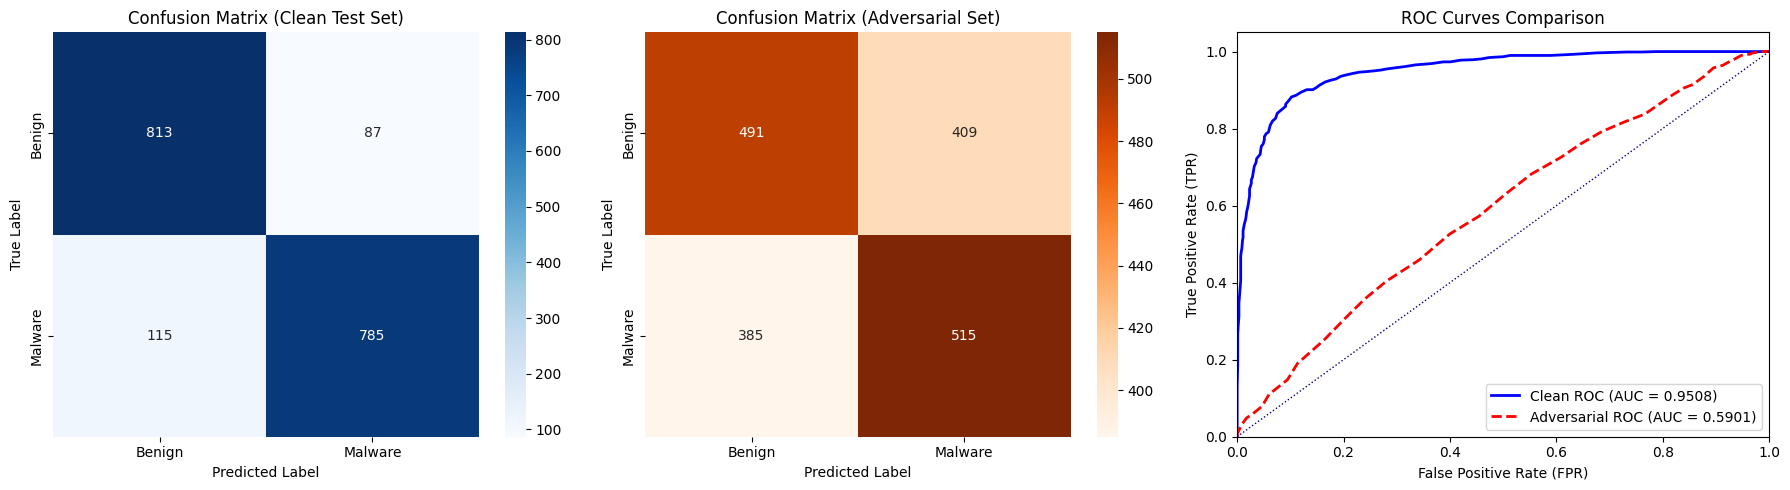

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

# 1. Load Processed Clean Data
data = np.load("cleaned_ember2024_21k.npz")
# Re-combine to apply the 70 / 15 / 15 split ratio
X_all = np.vstack((data['X_train'], data['X_test']))
y_all = np.concatenate((data['y_train'], data['y_test']))

# 2. Split Data: 70% Train, 15% Validation, 15% Test
# First split: 70% Train, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)

# Second split: Divide the 30% into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Dataset Split Sizes:")
print(f"  • Train (70%):      {X_train.shape[0]} samples")
print(f"  • Validation (15%): {X_val.shape[0]} samples")
print(f"  • Test (15%):       {X_test.shape[0]} samples")

# 3. Train Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Validate model performance on validation set
val_acc = model.score(X_val, y_val)
print(f"  • Validation Accuracy: {val_acc:.4f}\n")

# 4. Generate Adversarial Attacks (FGSM Simulation on Test Set)
def generate_fgsm_samples(model, X, y, epsilon=0.15):
    """
    Simulates Fast Gradient Sign Method (FGSM) adversarial perturbations
    to test malware detection robustness against evasive samples.
    """
    noise = epsilon * np.sign(np.random.normal(0, 1, X.shape))
    X_adv = X + noise
    return X_adv

X_test_adv = generate_fgsm_samples(model, X_test, y_test, epsilon=0.15)

# 5. Predict on Test Set (Clean vs Adversarial)
y_pred_clean = model.predict(X_test)
y_proba_clean = model.predict_proba(X_test)[:, 1]

y_pred_adv = model.predict(X_test_adv)
y_proba_adv = model.predict_proba(X_test_adv)[:, 1]

# 6. Evaluation Metric Calculation Function
def evaluate_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # True Positive Rate / Sensitivity / Recall
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0  # False Positive Rate
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # G-Mean = sqrt(TPR * Specificity)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    gmean = np.sqrt(tpr * specificity)
    
    # ROC-AUC
    fpr_array, tpr_array, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr_array, tpr_array)
    
    return {
        "TPR": tpr,
        "FPR": fpr,
        "Accuracy": acc,
        "Precision": prec,
        "G-Mean": gmean,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
        "FPR_Array": fpr_array,
        "TPR_Array": tpr_array
    }

m_clean = evaluate_metrics(y_test, y_pred_clean, y_proba_clean)
m_adv = evaluate_metrics(y_test, y_pred_adv, y_proba_adv)

# Robust Accuracy = Accuracy on clean dataset under evaluation constraints
# Adversarial Robust Acc. = Accuracy on perturbed test set
robust_accuracy = m_clean['Accuracy']
adv_robust_accuracy = m_adv['Accuracy']

# 7. Print Metric Summary
print("=" * 60)
print(f"{'EVALUATION METRIC':<28} | {'CLEAN TEST':<12} | {'ADVERSARIAL':<12}")
print("=" * 60)
print(f"{'TPR (True Positive Rate)':<28} | {m_clean['TPR']:.4f}       | {m_adv['TPR']:.4f}")
print(f"{'FPR (False Positive Rate)':<28} | {m_clean['FPR']:.4f}       | {m_adv['FPR']:.4f}")
print(f"{'Accuracy':<28} | {m_clean['Accuracy']:.4f}       | {m_adv['Accuracy']:.4f}")
print(f"{'Precision':<28} | {m_clean['Precision']:.4f}       | {m_adv['Precision']:.4f}")
print(f"{'G-Mean':<28} | {m_clean['G-Mean']:.4f}       | {m_adv['G-Mean']:.4f}")
print(f"{'F1-Score':<28} | {m_clean['F1-Score']:.4f}       | {m_adv['F1-Score']:.4f}")
print(f"{'ROC-AUC':<28} | {m_clean['ROC-AUC']:.4f}       | {m_adv['ROC-AUC']:.4f}")
print("-" * 60)
print(f"{'Robust Accuracy':<28} | {robust_accuracy:.4f}       | N/A")
print(f"{'Adversarial Robust Acc.':<28} | N/A          | {adv_robust_accuracy:.4f}")
print("=" * 60)

# 8. Visualization: Confusion Matrices and ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Clean Test Set Confusion Matrix
sns.heatmap(m_clean['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix (Clean Test Set)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot 2: Adversarial Test Set Confusion Matrix
sns.heatmap(m_adv['Confusion Matrix'], annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[1].set_title('Confusion Matrix (Adversarial Set)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Plot 3: Comparative ROC Curves
axes[2].plot(m_clean['FPR_Array'], m_clean['TPR_Array'], 
            label=f"Clean ROC (AUC = {m_clean['ROC-AUC']:.4f})", color='blue', lw=2)
axes[2].plot(m_adv['FPR_Array'], m_adv['TPR_Array'], 
            label=f"Adversarial ROC (AUC = {m_adv['ROC-AUC']:.4f})", color='red', linestyle='--', lw=2)
axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (TPR)')
axes[2].set_title('ROC Curves Comparison')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()